<a href="https://colab.research.google.com/github/Dheeraj637-ops/Space-Object-Detection-and-Classification/blob/main/Space_Object.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Install the ultralytics package for YOLO
!pip install ultralytics

# 2. Upload your zip file from your computer to Colab
from google.colab import files
uploaded = files.upload()  # Select your 'space_data.zip' file here

# 3. Unzip the dataset into the Colab environment
import zipfile
import os

zip_path = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/space_data')

print("Unzipping complete! Your files are stored in /content/space_data")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.9 MB/s eta 0:00:00


Saving space_data.zip.zip to space_data.zip (1).zip
Unzipping complete! Your files are stored in /content/space_data


In [ ]:
import pandas as pd

# Load the training metrics file
results_path = '/content/runs/detect/train/results.csv'
df = pd.read_csv(results_path)

# Clean up column names (YOLO sometimes adds spaces)
df.columns = df.columns.str.strip()

# Grab the final epoch's metrics
final_epoch = df.iloc[-1]

print("==================================================")
print("             YOLO FINAL METRICS SCORE             ")
print("==================================================")
print(f"Precision (B):   {final_epoch['metrics/precision(B)']:.4f}")
print(f"Recall (B):      {final_epoch['metrics/recall(B)']:.4f}")
print(f"mAP50 (B):       {final_epoch['metrics/mAP50(B)']:.4f}  <-- Accuracy threshold at 50% IoU")
print(f"mAP50-95 (B):    {final_epoch['metrics/mAP50-95(B)']:.4f} <-- Stricter overall accuracy")
print("==================================================")

             YOLO FINAL METRICS SCORE             
Precision (B):   0.5299
Recall (B):      0.5314
mAP50 (B):       0.5337  <-- Accuracy threshold at 50% IoU
mAP50-95 (B):    0.2692 <-- Stricter overall accuracy


Lets do it again to understand the depth of this project

## Step 1:- Lets install yolo v11 model

In [ ]:
!pip install ultralytics -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


# Step2:- Lets set up the data set from my drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Step 3:- lets create one folder and extract all the zip data set into that

In [ ]:
import os

os.makedirs("/content/satellite_dataset", exist_ok=True)

In [ ]:
import zipfile

zip_files = [
    "/content/drive/MyDrive/Dataset/satellite_part1.zip",
    "/content/drive/MyDrive/Dataset/satellite_part2.zip"
]

for z in zip_files:
    with zipfile.ZipFile(z, 'r') as zip_ref:
        zip_ref.extractall("/content/satellite_dataset")

print("Extraction Complete!")

Extraction Complete!


# Step 4:- Acessing my data set and store in var's

In [ ]:
# images
train_images = "/content/satellite_dataset/final_dataset/images/train"
val_images = "/content/satellite_dataset/final_dataset/images/val"
# mask
train_masks = "/content/satellite_dataset/final_dataset/mask/train"
val_masks = "/content/satellite_dataset/final_dataset/mask/val"
# boudning boxes
bbox_file = "/content/satellite_dataset/final_dataset/all_bbox.txt"

# Step 5:- Let me check what my data set and do some pre processing

In [ ]:
print("No. of images:", len(os.listdir(image_dir)))
print("No. of masks:", len(os.listdir(mask_dir)))

No. of images: 2518
No. of masks: 2517


ohhh one mask is missing

In [ ]:
import os

image_dir = "/content/satellite_dataset/Final_dataset/images/train"
mask_dir = "/content/satellite_dataset/Final_dataset/mask/train"

images = set(os.listdir(image_dir))
masks = set(os.listdir(mask_dir))

print("Images without masks:")
print(images - masks)

print("\nMasks without images:")
print(masks - images)

Images without masks:
{'img_resize_3095.png', 'img_resize_1236.png', 'img_resize_2873.png', 'img_resize_1006.png', 'img_resize_2839.png', 'img_resize_66.png', 'img_resize_1446.png', 'img_resize_2179.png', 'img_resize_148.png', 'img_resize_1419.png', 'img_resize_2085.png', 'img_resize_1949.png', 'img_resize_2820.png', 'img_resize_400.png', 'img_resize_1838.png', 'img_resize_2226.png', 'img_resize_1306.png', 'img_resize_3065.png', 'img_resize_41.png', 'img_resize_2183.png', 'img_resize_1713.png', 'img_resize_3089.png', 'img_resize_198.png', 'img_resize_1485.png', 'img_resize_2587.png', 'img_resize_2174.png', 'img_resize_1349.png', 'img_resize_2084.png', 'img_resize_2426.png', 'img_resize_248.png', 'img_resize_120.png', 'img_resize_1591.png', 'img_resize_392.png', 'img_resize_2818.png', 'img_resize_1669.png', 'img_resize_2228.png', 'img_resize_16.png', 'img_resize_1548.png', 'img_resize_2268.png', 'img_resize_2968.png', 'img_resize_2677.png', 'img_resize_2425.png', 'img_resize_1569.png', 

In [ ]:
print("First 10 image files:")
print(sorted(os.listdir(image_dir))[:10])

print("\nFirst 10 mask files:")
print(sorted(os.listdir(mask_dir))[:10])

First 10 image files:
['.DS_Store', 'img_resize_0.png', 'img_resize_1.png', 'img_resize_10.png', 'img_resize_100.png', 'img_resize_1003.png', 'img_resize_1004.png', 'img_resize_1005.png', 'img_resize_1006.png', 'img_resize_1007.png']

First 10 mask files:
['img_resize_0_mask.png', 'img_resize_1003_mask.png', 'img_resize_1004_mask.png', 'img_resize_1005_mask.png', 'img_resize_1006_mask.png', 'img_resize_1007_mask.png', 'img_resize_1008_mask.png', 'img_resize_1009_mask.png', 'img_resize_100_mask.png', 'img_resize_1010_mask.png']


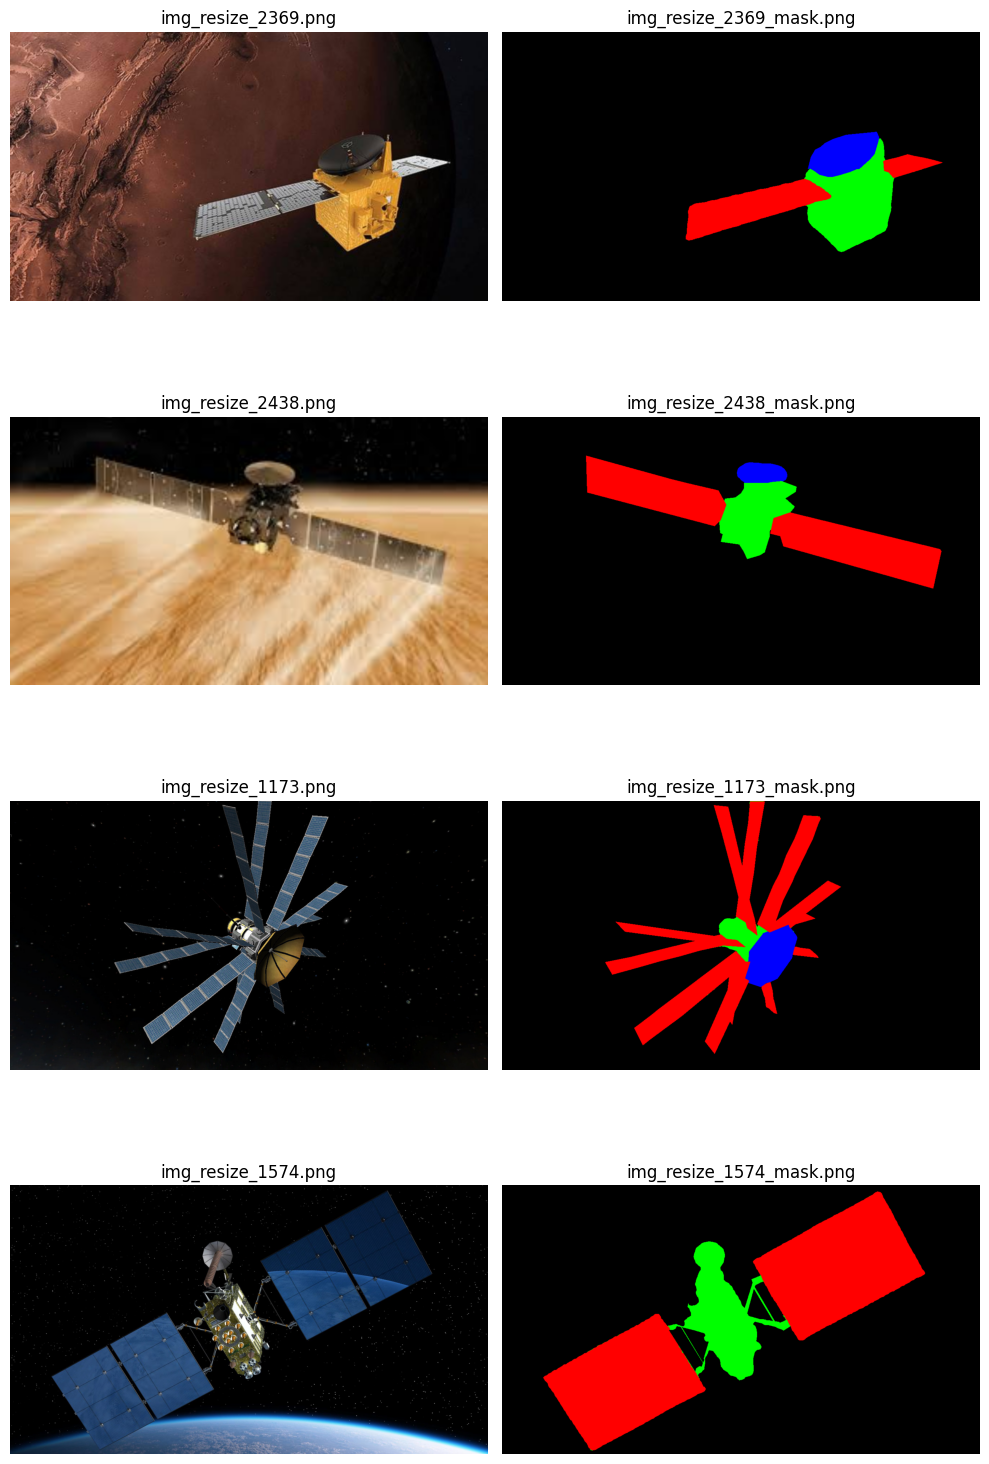

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

image_dir = "/content/satellite_dataset/Final_dataset/images/train"
mask_dir = "/content/satellite_dataset/Final_dataset/mask/train"

# .DS_Store and other hidden files are there lets remove them
images = [f for f in os.listdir(image_dir)
          if f.endswith(".png") and not f.startswith(".")]

# Keep only images that have a corresponding mask
valid_images = []

for img_name in images:
    mask_name = img_name.replace(".png", "_mask.png")
    if os.path.exists(os.path.join(mask_dir, mask_name)):
        valid_images.append(img_name)

sample = random.sample(valid_images, 4)

fig, axes = plt.subplots(4, 2, figsize=(10, 16))

for i, img_name in enumerate(sample):

    mask_name = img_name.replace(".png", "_mask.png")

    img = Image.open(os.path.join(image_dir, img_name))
    mask = Image.open(os.path.join(mask_dir, mask_name))

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(img_name)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask)
    axes[i, 1].set_title(mask_name)
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# Step:- 6 Lets train the Yolo v11 model

In [ ]:
bbox_path = "/content/satellite_dataset/Final_dataset/all_bbox.txt"

with open(bbox_path, "r") as f:
    for _ in range(5):
        print(f.readline())

{"1003": [[1142.0, 547.0, 296.0, 135.0]], "1004": [[728.0, 198.0, 542.0, 59.0], [212.0, 305.0, 0.0, 118.0], [1279.0, 437.0, 768.0, 85.0]], "1005": [[1214.0, 582.0, 322.0, 32.0]], "1006": [[1268.0, 685.0, 77.0, 30.0]], "1007": [[1194.0, 602.0, 107.0, 90.0]], "1008": [[1279.0, 517.0, 7.0, 179.0]], "1009": [[1057.0, 539.0, 144.0, 128.0]], "1010": [[1258.0, 651.0, 14.0, 41.0]], "1011": [[1087.0, 719.0, 221.0, 0.0]], "1012": [[1017.0, 530.0, 292.0, 195.0]], "1013": [[1114.0, 714.0, 175.0, 68.0]], "1014": [[1057.0, 268.0, 874.0, 111.0], [783.0, 305.0, 578.0, 78.0], [342.0, 719.0, 97.0, 319.0], [1279.0, 669.0, 1024.0, 191.0]], "1015": [[1257.0, 431.0, 26.0, 49.0]], "1016": [[1158.0, 611.0, 104.0, 108.0]], "1017": [[1021.0, 694.0, 323.0, 47.0]], "1018": [[1103.0, 309.0, 565.0, 96.0]], "1019": [[1169.0, 697.0, 37.0, 27.0]], "1020": [[287.0, 394.0, 144.0, 312.0], [480.0, 306.0, 251.0, 172.0], [280.0, 203.0, 105.0, 78.0], [1220.0, 348.0, 788.0, 139.0], [798.0, 458.0, 456.0, 165.0]], "1021": [[101

In [ ]:
import os
import ast

# -------------------------
# Paths
# -------------------------
ROOT = "/content/satellite_dataset/Final_dataset"

TRAIN_IMG = os.path.join(ROOT, "images", "train")
VAL_IMG = os.path.join(ROOT, "images", "val")

TRAIN_LABEL = os.path.join(ROOT, "labels", "train")
VAL_LABEL = os.path.join(ROOT, "labels", "val")

os.makedirs(TRAIN_LABEL, exist_ok=True)
os.makedirs(VAL_LABEL, exist_ok=True)

# -------------------------
# Image size
# -------------------------
IMG_W = 1280
IMG_H = 720

# -------------------------
# Read bbox dictionary
# -------------------------
with open(os.path.join(ROOT, "all_bbox.txt"), "r") as f:
    bbox_dict = ast.literal_eval(f.read())

print(f"Loaded {len(bbox_dict)} annotated images")

# -------------------------
# Convert to YOLO labels
# -------------------------
for img_id, boxes in bbox_dict.items():

    img_num = int(img_id)

    if 403 <= img_num <= 1002:
        label_folder = VAL_LABEL
    else:
        label_folder = TRAIN_LABEL

    label_path = os.path.join(label_folder, f"img_resize_{img_num}.txt")

    with open(label_path, "w") as out:

        for box in boxes:

            max_x, max_y, min_x, min_y = box

            x_center = ((min_x + max_x) / 2) / IMG_W
            y_center = ((min_y + max_y) / 2) / IMG_H

            width = (max_x - min_x) / IMG_W
            height = (max_y - min_y) / IMG_H

            # Single class = satellite
            out.write(f"0 {x_center} {y_center} {width} {height}\n")

print("✅ YOLO labels created successfully!")

Loaded 3117 annotated images
✅ YOLO labels created successfully!


In [ ]:
yaml_content = """
path: /content/satellite_dataset/Final_dataset

train: images/train
val: images/val

names:
  0: satellite
"""

with open("/content/satellite_dataset/Final_dataset/dataset.yaml", "w") as f:
    f.write(yaml_content)

print("✅ dataset.yaml created")

✅ dataset.yaml created


# Model selection


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
model.train(
    data="/content/satellite_dataset/Final_dataset/dataset.yaml",
    epochs=1,
    imgsz=640,
    batch=4
)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/satellite_dataset/Final_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d063b0ca7e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

metrics = model.val()

print(metrics.results_dict)

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3564.6±727.6 MB/s, size: 909.6 KB)
val: Scanning /content/satellite_dataset/Final_dataset/labels/val.cache... 600 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 600/600 139.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 2.9it/s 13.2s
                   all        600        735      0.793      0.721      0.789      0.483
Speed: 1.6ms preprocess, 3.7ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to /content/runs/detect/val
{'metrics/precision(B)': 0.7934913059835449, 'metrics/recall(B)': 0.7214326798146344, 'metrics/mAP50(B)': 0.7885462974607615, 'metrics/mAP50-95(B)': 0.48323555492418613, 'fitness': 0.48323555492418613}


In [ ]:
from ultralytics import YOLO
yaml_path = "/content/satellite_dataset/Final_dataset/dataset.yaml"
model = YOLO("yolo11n.pt")

results = model.train(
    data=yaml_path,

    epochs=100,
    imgsz=640,
    batch=16,

    optimizer="auto",      # Let YOLO choose the best optimizer
    lr0=0.005,             # Lower LR for stable fine-tuning
    lrf=0.01,              # Typical final LR ratio
    momentum=0.937,
    weight_decay=0.0005,

    warmup_epochs=3,
    cos_lr=True,

    augment=True,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2.0,             # Added
    perspective=0.0005,    # Added

    flipud=0.2,            # Slightly reduced
    fliplr=0.5,

    mosaic=1.0,
    mixup=0.1,
    close_mosaic=10,       # Disable mosaic in last 10 epochs

    patience=20,

    save=True,
    save_period=10,

    project="/content/drive/MyDrive/space_yolov11_runs",
    name="train_v1",
    exist_ok=True,

    device=0,
    workers=2,
    cache=True,            # Faster training in Colab
    amp=True,              # Mixed precision (faster on GPU)
    verbose=True
)

print(f"Best model: {results.save_dir}/weights/best.pt")

Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/satellite_dataset/Final_dataset/dataset.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_v1, nbs=64, nms=False, opset=None, optimize=False